In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from msresist.pre_processing import preprocessing
from msresist.clustering import DDMC
from msresist.figures.common import plotMotifs

matplotlib.rcParams["font.sans-serif"] = "Arial"
sns.set(
    style="white",
    font_scale=1,
    color_codes=True,
    palette="colorblind",
    rc={"grid.linestyle": "dotted", "axes.linewidth": 0.6},
)

In [2]:
# Import siganling data
X = preprocessing(
    AXLm_ErlAF154=True, Vfilter=True, FCfilter=True, log2T=True, mc_row=True
)
d = X.select_dtypes(include=["float64"]).T
i = X.select_dtypes(include=["object"])

# Fit DDMC
ddmc = DDMC(
    i, n_components=5, SeqWeight=2, distance_method="PAM250", random_state=5
).fit(d)

In [3]:
X.insert(0, "DDMC cluster", ddmc.labels())

In [4]:
import os

os.makedirs("msresist/results", exist_ok=True)
X[["DDMC cluster", "Gene", "Position"]].to_csv(
    "msresist/results/AXL_clusters.csv", index=False
)

/home/creixell/AXLomics/msresist/clustering.py:176: RuntimeWarning: invalid value encountered in divide
  pssm /= back_pssm.copy()
/home/creixell/AXLomics/msresist/clustering.py:192: RuntimeWarning: divide by zero encountered in log2
  pssm.loc[p_site, 5] = np.log2(clSeq.loc[p_site, 5] / tm)
/home/creixell/AXLomics/msresist/clustering.py:176: RuntimeWarning: invalid value encountered in divide
  pssm /= back_pssm.copy()
/home/creixell/AXLomics/msresist/clustering.py:192: RuntimeWarning: divide by zero encountered in log2
  pssm.loc[p_site, 5] = np.log2(clSeq.loc[p_site, 5] / tm)
/home/creixell/AXLomics/msresist/clustering.py:176: RuntimeWarning: invalid value encountered in divide
  pssm /= back_pssm.copy()
/home/creixell/AXLomics/msresist/clustering.py:176: RuntimeWarning: invalid value encountered in divide
  pssm /= back_pssm.copy()
/home/creixell/AXLomics/msresist/clustering.py:192: RuntimeWarning: divide by zero encountered in log2
  pssm.loc[p_site, 5] = np.log2(clSeq.loc[p_site,

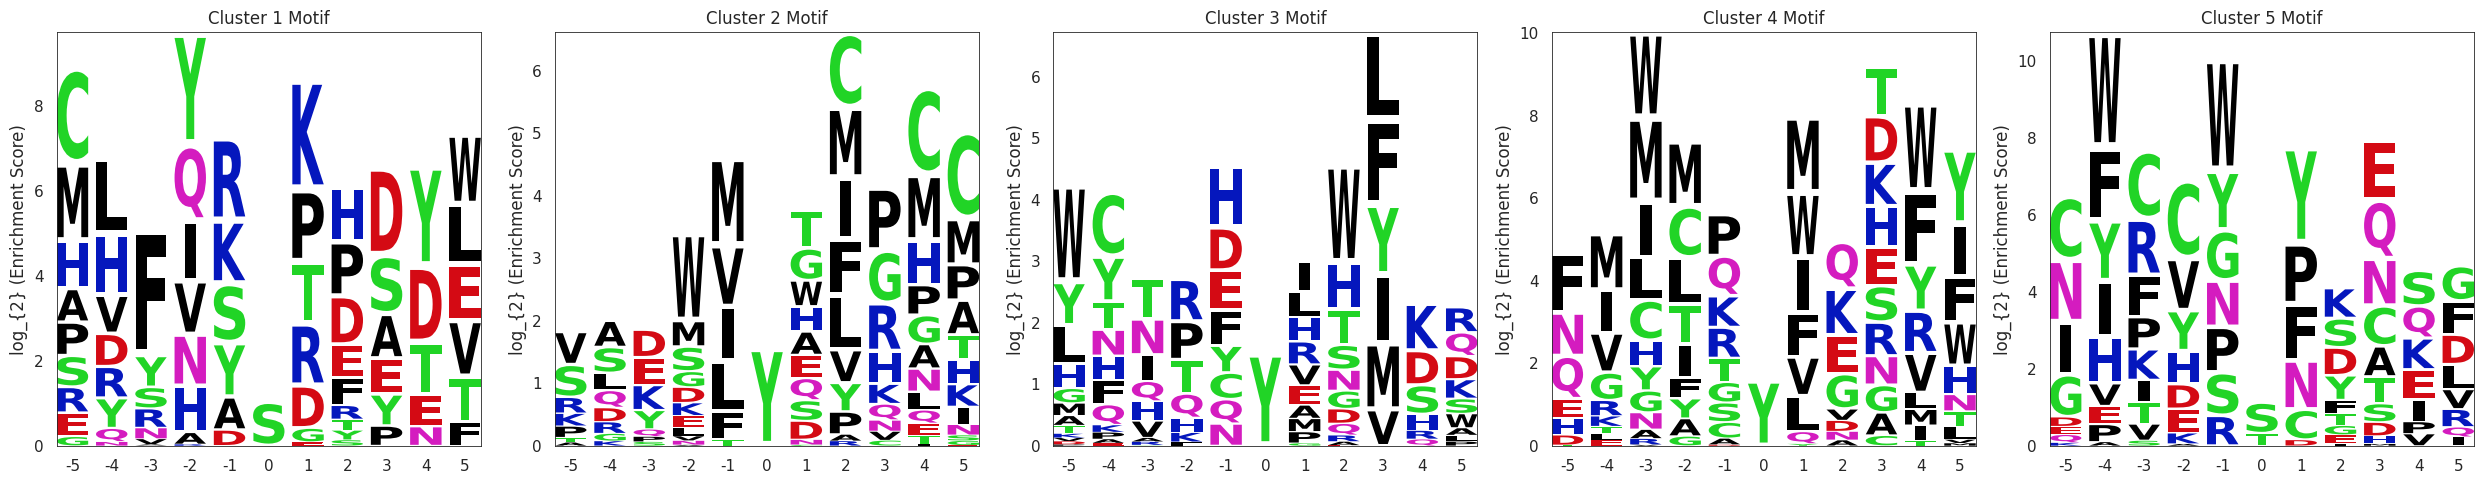

In [5]:
import os

os.makedirs("output", exist_ok=True)
_, ax = plt.subplots(1, 5, figsize=(25, 5))
pssms, _ = ddmc.pssms(PsP_background=False)
plotMotifs(
    [pssms[0], pssms[1], pssms[2], pssms[3], pssms[4]],
    axes=ax,
    titles=["Cluster 1", "Cluster 2", "Cluster 3", "Cluster 4", "Cluster 5"],
)
plt.tight_layout()